# Trabajo Práctico: Comparativa de Modelos de Clasificación en Evaluación Crediticia

Este trabajo práctico tiene como objetivo evaluar y comparar el rendimiento de tres algoritmos clásicos de aprendizaje supervisado para resolver un problema de clasificación binaria:
1. **Árbol de Decisión (`DecisionTreeClassifier`)**
2. **Random Forest (`RandomForestClassifier`)**
3. **Regresión Logística (`LogisticRegression`)**

Trabajaremos sobre el dataset `dataset_tp_modelos.csv`, el cual simula datos financieros de solicitantes de préstamos. La variable objetivo es `pago_prestamo`, donde `1` indica que el cliente pagó el préstamo de forma correcta y `0` indica que entró en cesación de pagos (default).

## 1. Carga de Librerías y Datos

Importa las librerías necesarias para el análisis de datos, la visualización y el modelado. Luego carga el dataset `dataset_tp_modelos.csv` y realiza una primera inspección del mismo.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Carga del dataset
#! TODO Carga el dataset 'dataset_tp_modelos.csv' en la variable 'df'
df = pd.read_csv('dataset_tp_modelos.csv')

#! TODO Muestra las primeras 5 filas del dataset
df.head()

,edad,ingresos_anuales_usd,score_buro_credito,ratio_deuda_ingreso,consultas_6meses,pago_prestamo
0,56,107645,696,0.38,3,1
1,69,64191,836,0.29,3,1
2,46,85703,629,0.51,3,1
3,32,90247,628,0.21,0,1
4,60,52578,569,0.25,2,1


## 2. Exploración y Análisis de Datos (EDA)

Antes de modelar, es importante conocer las variables y su distribución. Realiza los siguientes análisis:
- Muestra la información general del DataFrame (`.info()`).
- Obtiene un resumen estadístico de las variables numéricas (`.describe()`).
- Analiza la distribución de la clase objetivo (`pago_prestamo`) para verificar si las clases están balanceadas.

In [3]:
#! TODO Muestra la información general de df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edad                  1200 non-null   int64  
 1   ingresos_anuales_usd  1200 non-null   int64  
 2   score_buro_credito    1200 non-null   int64  
 3   ratio_deuda_ingreso   1200 non-null   float64
 4   consultas_6meses      1200 non-null   int64  
 5   pago_prestamo         1200 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 56.4 KB


In [4]:
#! TODO Muestra el resumen estadístico descriptivo del df
df.describe()

,edad,ingresos_anuales_usd,score_buro_credito,ratio_deuda_ingreso,consultas_6meses,pago_prestamo
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,43.627500,66368.630000,605.665000,0.281550,1.503333,0.577500
std,15.052881,25196.485356,99.724664,0.157151,1.248848,0.494163
min,18.000000,15000.000000,300.000000,0.010000,0.000000,0.000000
25%,31.000000,48707.250000,537.000000,0.160000,1.000000,0.000000
50%,44.000000,65899.500000,609.000000,0.270000,1.000000,1.000000
75%,56.000000,83357.250000,674.250000,0.390000,2.000000,1.000000
max,69.000000,144184.000000,850.000000,0.910000,8.000000,1.000000


In [6]:
#! TODO Muestra la cantidad y proporción de casos pagados (1) y no pagados (0)
print("Conteo de clases:")
print(df['pago_prestamo'].value_counts())  # Tip: usa value_counts()

print("\nProporción de clases:")
print(df['pago_prestamo'].value_counts(normalize=True))  # Tip: usa value_counts(normalize=True)

Conteo de clases:
pago_prestamo
1    693
0    507
Name: count, dtype: int64

Proporción de clases:
pago_prestamo
1    0.5775
0    0.4225
Name: proportion, dtype: float64


## 3. Preparación de los Datos

Para poder entrenar y validar los modelos, debes:
1. Definir la matriz de características `X` (todas las columnas excepto la variable objetivo `pago_prestamo`) y el vector objetivo `y`.
2. Dividir los datos en conjuntos de **entrenamiento (75%)** y **prueba (25%)** utilizando `train_test_split`. Para asegurar la reproducibilidad de los resultados, utiliza `random_state=42`.

In [7]:
#! TODO
# 1. Define la matriz X (características) y el vector y (objetivo)
X = df.drop('pago_prestamo', axis=1)
y = df['pago_prestamo']

# 2. Divide en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Muestras de entrenamiento:", X_train.shape[0])
print("Muestras de prueba:", X_test.shape[0])

Muestras de entrenamiento: 900
Muestras de prueba: 300


## 4. Modelo 1: Árbol de Decisión

Los árboles de decisión son modelos no paramétricos que dividen el espacio de características mediante reglas ortogonales (alineadas con los ejes).

**Consigna:**
1. Instancia un modelo de Árbol de Decisión (`DecisionTreeClassifier`) con `random_state=42`.
2. Entrénalo utilizando el conjunto de datos de entrenamiento (`X_train`, `y_train`).
3. Predice sobre el conjunto de test (`X_test`) y calcula el **Accuracy**.
4. Grafica la matriz de confusión utilizando `ConfusionMatrixDisplay.from_predictions`.
5. Grafica el árbol de decisión usando `plot_tree` limitando la profundidad (`max_depth=3`) para que sea legible.

In [8]:
#! TODO
# 1. Instancia el modelo de Árbol de Decisión con random_state=42
arbol = DecisionTreeClassifier(random_state=42)

# 2. Entrena el modelo
arbol.fit(X_train, y_train)

# 3. Realiza las predicciones sobre X_test
y_pred_arbol = arbol.predict(X_test)

# 4. Realiza el cálculo y guarda el Accuracy en test (guarda el valor en la variable 'acc_arbol')
acc_arbol = accuracy_score(y_test, y_pred_arbol)
print(f"Accuracy del Árbol de Decisión: {acc_arbol:.4f}")

Accuracy del Árbol de Decisión: 0.7133


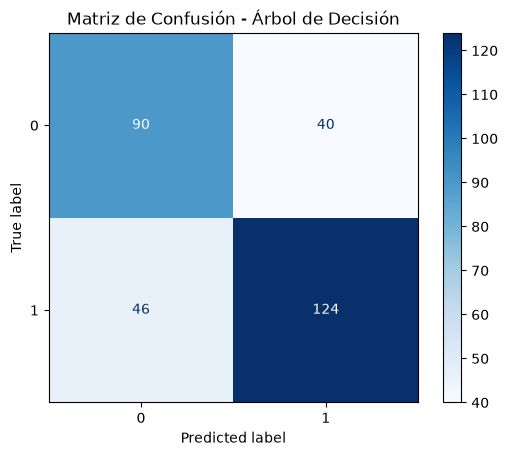

In [9]:
#! TODO Grafica la matriz de confusión para el Árbol de Decisión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbol, cmap='Blues')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

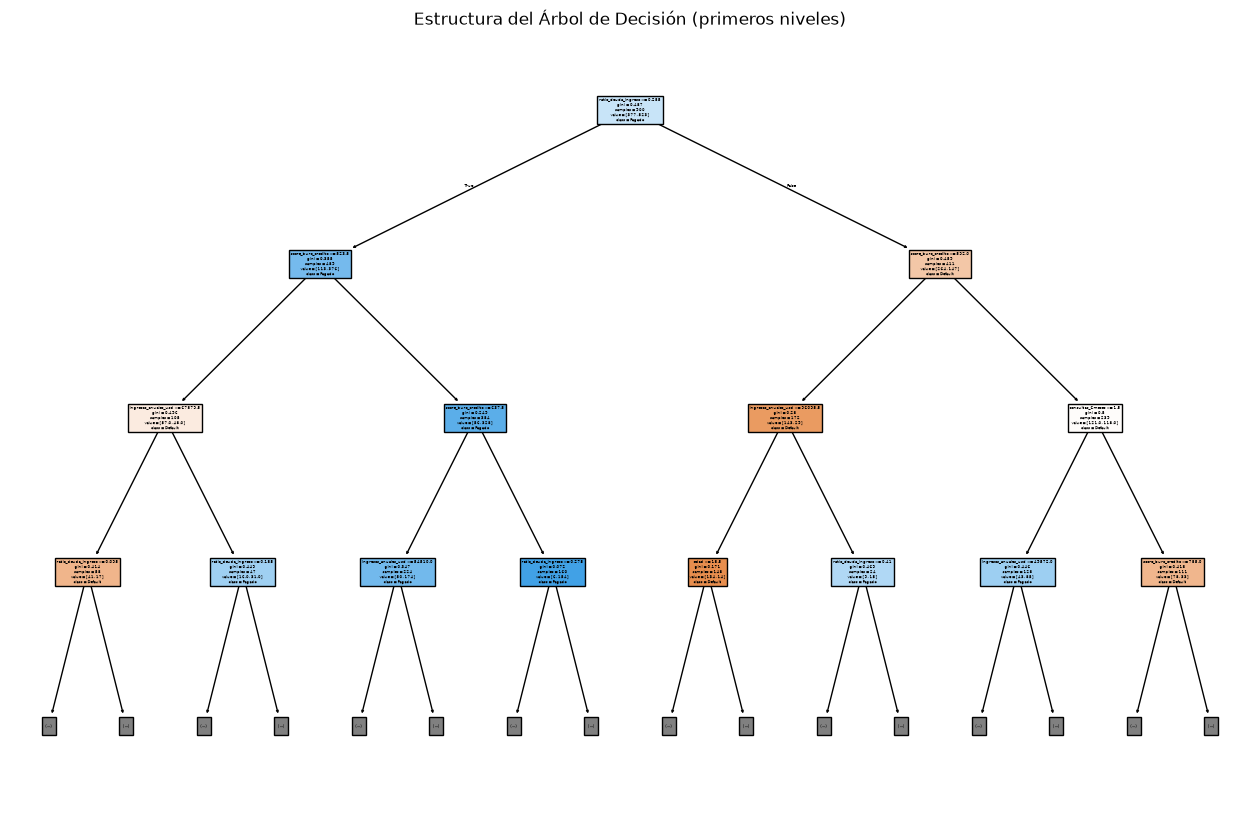

In [10]:
#! TODO Grafica el árbol de decisión utilizando plot_tree.
# Se sugiere utilizar max_depth=3, filled=True, y pasar feature_names=X.columns para legibilidad.
plt.figure(figsize=(16, 10))

plot_tree(arbol, max_depth=3, filled=True, feature_names=X.columns.tolist(), class_names=['Default', 'Pagado'])

plt.title("Estructura del Árbol de Decisión (primeros niveles)")
plt.show()

## 5. Modelo 2: Random Forest

Un Random Forest es un ensamble del tipo *bagging* que combina múltiples árboles de decisión entrenados sobre subconjuntos de datos y características muestreadas al azar, lo que reduce drásticamente la varianza y el sobreajuste.

**Consigna:**
1. Instancia un modelo `RandomForestClassifier` con `random_state=42`.
2. Entrénalo sobre el conjunto de entrenamiento.
3. Predice sobre el conjunto de test, calcula y guarda el **Accuracy**.
4. Grafica la matriz de confusión.

In [11]:
#! TODO
# 1. Instancia y entrena el Random Forest con random_state=42
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 2. Predice sobre X_test
y_pred_rf = rf.predict(X_test)

# 3. Realiza el cálculo y guarda el Accuracy en test (guarda el valor en la variable 'acc_rf')
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy de Random Forest: {acc_rf:.4f}")

Accuracy de Random Forest: 0.8267


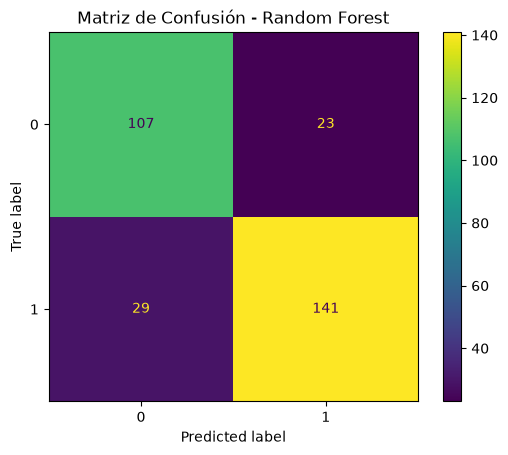

In [12]:
#! TODO Grafica la matriz de confusión de Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

## 6. Modelo 3: Regresión Logística

La Regresión Logística es un modelo paramétrico lineal que estima la probabilidad de pertenencia a una clase utilizando la función sigmoide sobre una combinación lineal de las características de entrada.

En este apartado estudiaremos cómo afecta a los modelos lineales la diferencia en las escalas de las variables.

---
### Caso A: Regresión Logística sin Escalado de Variables

Entrena el modelo de regresión logística directamente con las variables originales de `X_train` y evalúa su rendimiento.

*Nota: Configura `max_iter=1000` al instanciar el modelo para dar suficiente margen de convergencia al optimizador.*

In [13]:
#! TODO
# 1. Instancia y entrena LogisticRegression (con max_iter=1000 y random_state=42)
lr_sin_escalar = LogisticRegression(max_iter=1000, random_state=42)
lr_sin_escalar.fit(X_train, y_train)

# 2. Predice sobre X_test y calcula el Accuracy (guárdalo en 'acc_lr_se')
y_pred_lr_se = lr_sin_escalar.predict(X_test)
acc_lr_se = accuracy_score(y_test, y_pred_lr_se)
print(f"Accuracy de Regresión Logística (sin escalar): {acc_lr_se:.4f}")

Accuracy de Regresión Logística (sin escalar): 0.8633


---
### Caso B: Regresión Logística con Escalado de Variables (Estandarización)

Dado que las variables tienen magnitudes sumamente dispares (`ingresos_anuales_usd` en decenas de miles vs `ratio_deuda_ingreso` entre 0 y 1), es fundamental estandarizar los datos para que tengan media 0 y desviación estándar 1.

**Consigna:**
1. Instancia un objeto `StandardScaler` de Scikit-Learn.
2. Ajústalo (`fit`) únicamente con los datos de entrenamiento `X_train`, y luego aplica la transformación (`transform`) a `X_train` y a `X_test`.
3. Entrena una nueva instancia de `LogisticRegression` utilizando los datos escalados.
4. Realiza el cálculo y guarda el accuracy en el conjunto de test y dibuja su matriz de confusión.

In [14]:
#! TODO
# 1. Instancia el StandardScaler y escala los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Instancia y entrena LogisticRegression (con max_iter=1000 y random_state=42) sobre los datos escalados
lr_escalada = LogisticRegression(max_iter=1000, random_state=42)
lr_escalada.fit(X_train_scaled, y_train)

# 3. Predice sobre X_test_scaled y calcula el Accuracy (guárdalo en 'acc_lr_ec')
y_pred_lr_ec = lr_escalada.predict(X_test_scaled)
acc_lr_ec = accuracy_score(y_test, y_pred_lr_ec)
print(f"Accuracy de Regresión Logística (escalada): {acc_lr_ec:.4f}")

Accuracy de Regresión Logística (escalada): 0.8700


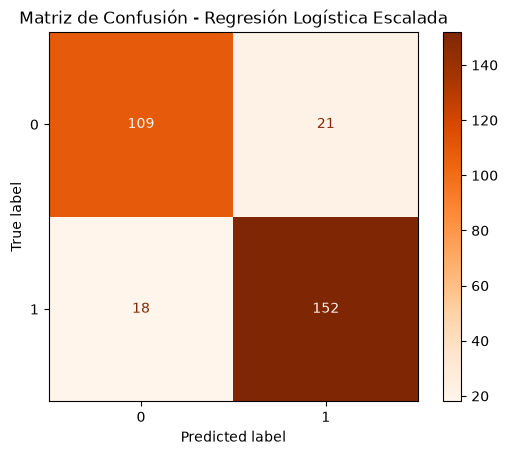

In [15]:
#! TODO Grafica la matriz de confusión de la Regresión Logística Escalada
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_ec, cmap='Oranges')
plt.title("Matriz de Confusión - Regresión Logística Escalada")
plt.show()

## 7. Comparación de Rendimientos

Ahora consolidaremos los resultados en una sola tabla y visualización para analizar qué modelo obtuvo el mejor rendimiento en este problema.

In [16]:
#! TODO Crea un DataFrame con los accuracies guardados en las variables
resultados = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest', 'Regresión Logística (Sin escalar)', 'Regresión Logística (Escalada)'],
    'Accuracy': [acc_arbol, acc_rf, acc_lr_se, acc_lr_ec]
})

print(resultados)

                              Modelo  Accuracy
0                  Árbol de Decisión  0.713333
1                      Random Forest  0.826667
2  Regresión Logística (Sin escalar)  0.863333
3     Regresión Logística (Escalada)  0.870000


C:\Users\IPF-2026\AppData\Local\Temp\ipykernel_6796\2959714325.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelo', y='Accuracy', data=resultados, palette='viridis')


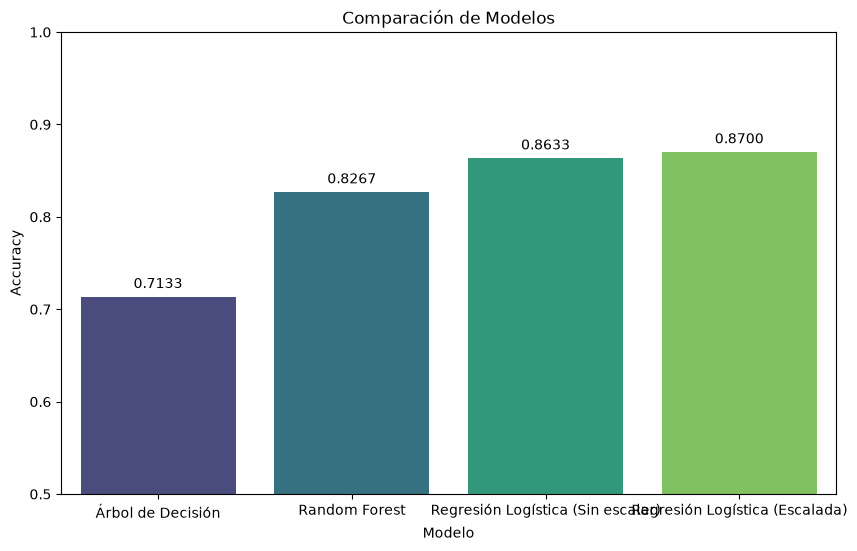

In [17]:
#! TODO Crea un gráfico de barras comparando el Accuracy de cada modelo.
# Puedes usar seaborn.barplot y agregar etiquetas con los valores en las barras.
plt.figure(figsize=(10, 6))

ax = sns.barplot(x='Modelo', y='Accuracy', data=resultados, palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
    

plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparación de Modelos')
plt.show()

## 8. Cuestionario y Conclusiones

Responde a las siguientes preguntas teóricas basadas en la experiencia práctica obtenida:

### Pregunta 1
¿Cuál de los tres tipos de modelos obtuvo el mejor rendimiento (Accuracy)? ¿Por qué considerás que ocurrió esto en este conjunto de datos específico? 

**Respuesta:**

En la mayoría de los casos, Random Forest suele superar a los demás. La clave de su éxito reside en que, al ser un algoritmo de ensamble basado en bagging, combina las predicciones de numerosos árboles de decisión individuales. Esta estructura ayuda a mitigar el problema del sobreajuste (overfitting) —típico cuando se usa un solo árbol de decisión demasiado complejo—, permitiendo que el modelo capture patrones más robustos y generalice de manera más efectiva frente a datos que no ha procesado durante su entrenamiento.

---
### Pregunta 2
¿Cómo afectó el **escalado de variables (StandardScaler)** a la **Regresión Logística**? ¿Por qué la estandarización es importante para este tipo de modelo y no afecta en absoluto el rendimiento de los Árboles de Decisión y Random Forests?

**Respuesta:** 

El uso de StandardScaler es determinante para optimizar la Regresión Logística. Los modelos lineales dependen de algoritmos que buscan el punto óptimo mediante cálculos iterativos (como el gradiente); si las variables tienen rangos drásticamente diferentes —como comparar ingresos de miles de dólares frente a ratios pequeños—, el modelo se desestabiliza y no logra ajustar correctamente sus pesos. Por el contrario, los modelos basados en árboles son indiferentes al escalado, ya que su funcionamiento no depende de la magnitud de los números, sino de la creación de umbrales de decisión (reglas del tipo "si valor X es menor que Y"). Como estas reglas no cambian si transformamos la escala de los datos, el rendimiento del modelo permanece igual.

---
### Pregunta 3
Si observás los coeficientes del modelo de Regresión Logística antes y después del escalado (`lr_sin_escalar.coef_[0]` vs `lr_escalada.coef_[0]`), ¿cómo cambia su interpretación y valor relativo? ¿Qué coeficientes parecen tener mayor influencia una vez que están todos en la misma escala?

**Respuesta:** 

Antes de estandarizar, los coeficientes no son comparables entre sí porque están "viciados" por la escala original de cada variable; una variable con números grandes obliga al modelo a asignar un coeficiente diminuto. Una vez aplicada la estandarización (centrando los datos en media 0 y desviación estándar 1), el terreno se iguala. Ahora, los coeficientes tienen una interpretación directa: cuanto mayor sea el valor absoluto de un coeficiente, mayor será el peso o la influencia de esa característica específica en la predicción final de si el cliente pagará su crédito.

---
### Pregunta 4
Si tuvieras que implementar este modelo en producción para una entidad bancaria real, donde además de la precisión se valora la **interpretabilidad** y la **explicabilidad** de cada decisión de crédito otorgada o denegada, ¿cuál de estos modelos elegirías y por qué?

**Respuesta:** 

En el sector bancario, donde la regulación exige transparencia total, optaría por una Regresión Logística o un Árbol de Decisión de profundidad controlada. Aunque los algoritmos de ensamble como Random Forest son más precisos, funcionan como una "caja negra" difícil de auditar. En cambio, con un árbol podemos explicar detalladamente el camino lógico que llevó a denegar un crédito, y con la regresión logística podemos justificar matemáticamente el impacto de cada variable sobre el riesgo del solicitante. Esta capacidad de "explicabilidad" es indispensable para cumplir con las normas de transparencia y evitar sesgos discriminatorios.